In [1]:
#Fix Numpy issue with force re-install
!pip install numpy==1.26.4 pandas==2.2.2 langchain-chroma==0.2.2 --force-reinstall

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.2/65.2 kB 4.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.3/67.3 kB 4.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.7/57.7 kB 3.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 115.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.0/13.0 MB 90.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 611.1/611.1 kB 40.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 84.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.3/423.3 kB 29.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 229.9/229.9 kB 17.4 MB/

In [1]:
#install all necessary libraries
!pip install langchain langchain_community langchain_chroma
!pip install -qU langchain-openai
!pip install pypdf pillow
!pip install rouge-score
!pip install sentence-transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 29.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.9/50.9 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.3/61.3 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 18.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.3/302.3 kB 4.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for rouge-score: filename=rouge_score-0.1.2-py3-none-any.whl size=24934 sha256=5538bb28ded73639948503257e76c1fba95a159afc2d5dfebdc89e93dbb64ed6
  Stored in directory: /root/.cache/pip/wheels/1e/19/43/8a442dc83660ca25e163e1bd1f89919284ab0d0c1475475148
Successfully built rouge-score
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 115.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 96.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
import nltk
import pandas as pd
nltk.download('punkt')
nltk.download('punkt_tab')
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from rouge_score import rouge_scorer
from sentence_transformers import SentenceTransformer, util
import bs4
from langchain import hub
from langchain_chroma import Chroma
from langchain_community.document_loaders import WebBaseLoader
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnablePassthrough
from langchain_openai import OpenAIEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter

import getpass
import os
from langchain_openai import ChatOpenAI
from langchain_community.document_loaders import PyPDFLoader
from google.colab import drive
from langchain_community.document_loaders import PyPDFDirectoryLoader
from langchain_core.vectorstores import InMemoryVectorStore
from langchain_core.chat_history import BaseChatMessageHistory
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain.chains import create_retrieval_chain
from langchain.chains.combine_documents import create_stuff_documents_chain
from langchain_community.llms import HuggingFaceEndpoint

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [76]:
from dotenv import load_dotenv
import os

In [77]:
load_dotenv()

False

In [78]:
openai_api_key = os.getenv("OPENAI_API_KEY")

In [79]:
langchain_key=os.getenv("LANGCHAIN_API_KEY")

In [80]:
langchain_tracing=os.getenv("LANGCHAIN_TRACING_V2")

In [5]:
#load stat 203 data folder from Drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
def title_from_filename(file_path):
    filename = os.path.basename(file_path)
    if filename.startswith('unit'):
        unit_number = filename.split('_')[1].replace('.pdf', '')
        return f"Unit {unit_number}"
    elif filename.startswith('textbook'):
        chapter_number = filename.split('_')[2].replace('.pdf', '')
        return f"Textbook Chapter {chapter_number}"
    return "Unknown"

In [7]:
#Read pdf data and label unit and tetxbook chapters accordingly
def load_documents():
  file_path='/content/drive/MyDrive/project_rag_data'
  loader = PyPDFDirectoryLoader(file_path)
  docs = loader.load()
  unit_topics = {
    'unit_01.pdf': 'Introduction to Probability - 1',
    'unit_02.pdf': 'Introduction to Probability - 2',
    'unit_03.pdf': 'Summarizing Distributions',
    'unit_04.pdf': 'Conditional Expectation and the Best Linear Predictor',
    'unit_05.pdf': 'Statistics,Parameters and Estimators',
    'unit_06.pdf': 'Hypothesis Testing - 1',
    'unit_07.pdf': 'Hypothesis Testing - 2',
    'unit_08.pdf': 'Introduction to Regression - 1',
    'unit_09.pdf': 'Introduction to Rgeression - 2',
    'unit_10.pdf': 'Questions of Description',
    'unit_11.pdf': 'Questions of Causation',
    'unit_12.pdf': 'Importance of the Classical Linear Model',
    'unit_13.pdf': 'Reproducible Research',
    'unit_14.pdf': 'Properties of Maximum Likelihood Estimators'
}

  # Manually define the topics for the textbook PDFs
  textbook_topics = {
    'textbook_chapter_01.pdf': 'Probability Theory',
    'textbook_chapter_02.pdf': 'Summarizing Distributions',
    'textbook_chapter_03.pdf': 'Learning from Random Samples',
    'textbook_chapter_04.pdf': 'Regression',
    'textbook_chapter_05.pdf': 'Parametric Models',
    'textbook_chapter_06.pdf': 'Missing Data',
    'textbook_chapter_07.pdf': 'Causal Inference'}

  for doc in docs:
    file_path = doc.metadata.get('source', '')

    # Add unit or textbook title based on the filename
    title = title_from_filename(file_path)
    doc.metadata['title'] = title

    # Determine if it's a unit or textbook PDF
    file_name = os.path.basename(file_path)

    if file_name in unit_topics:
        doc.metadata['topic'] = unit_topics[file_name]
        doc.metadata['type'] = 'unit'
    elif file_name in textbook_topics:
        doc.metadata['topic'] = textbook_topics[file_name]
        doc.metadata['type'] = 'textbook'
    else:
        doc.metadata['topic'] = 'Unknown Topic'
        doc.metadata['type'] = 'unknown'
    return docs


In [8]:
#Chunk text and create retriever
def create_retriever(docs,chunk):
  text_splitter = RecursiveCharacterTextSplitter(chunk_size=chunk, chunk_overlap=200)
  splits = text_splitter.split_documents(docs)
  vectorstore = Chroma.from_documents(documents=splits, embedding=OpenAIEmbeddings())
  retriever = vectorstore.as_retriever(search_type="similarity_score_threshold", search_kwargs={"score_threshold": 0.3,"k":20})
  return retriever


In [9]:
def format_docs(docs):
    return "\n\n".join(doc.page_content for doc in docs)

In [27]:
def create_rag_chain(retriever,model_name="gpt-4o-mini"):
  if model_name == "gpt-4o-mini":
        llm = ChatOpenAI(model_name="gpt-4o-mini")
  elif model_name == "mixtral":
    llm = HuggingFaceEndpoint(
    repo_id="mistralai/Mixtral-8x7B-Instruct-v0.1",
    task="text-generation"
)
  elif model_name == "llama3":
    llm = HuggingFaceEndpoint(
    repo_id="meta-llama/Llama-3.2-3B-Instruct",
    task="text-generation"
)
  else:
      raise ValueError(f"Unsupported model: {model_name}")

  system_prompt = (
    "You are an assistant for question-answering tasks. "
    "Use the following pieces of retrieved context to answer "
    "the question. If you don't know the answer, say that you "
    "don't know."
    "\n\n"
    "{context}"
)
  prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system_prompt),
        ("human", "{input}"),
    ]
)
  question_answer_chain = create_stuff_documents_chain(llm, prompt)
  rag_chain = create_retrieval_chain(retriever, question_answer_chain)
  return rag_chain

In [28]:
def get_rag_output(question,conversational_rag_chain):
  output=conversational_rag_chain.invoke(
    {"input":question}
)
  return output

In [ ]:
#baseline
# docs=load_documents()
# retriever=create_retriever(docs)
# conversational_rag_chain=create_rag_chain(retriever)

In [12]:
#Compute BLEU Score
def calculate_bleu_score(reference_answer, prediction_answer):
    reference_tokens = [nltk.word_tokenize(reference_answer.lower())]
    prediction_tokens = nltk.word_tokenize(prediction_answer.lower())
    smoothie = SmoothingFunction().method4
    score = sentence_bleu(reference_tokens, prediction_tokens, smoothing_function=smoothie)
    return score

In [48]:
#Compute ROUGE scores
def calculate_rouge_scores(predicted_answer, reference_answer):
    scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
    scores = scorer.score(reference_answer, predicted_answer)

    rouge_results = {
        'rouge1': {
            'precision': round(scores['rouge1'].precision, 4),
            'recall': round(scores['rouge1'].recall, 4),
            'f1': round(scores['rouge1'].fmeasure, 4),
        },
        'rouge2': {
            'precision': round(scores['rouge2'].precision, 4),
            'recall': round(scores['rouge2'].recall, 4),
            'f1': round(scores['rouge2'].fmeasure, 4),
        },
        'rougeL': {
            'precision': round(scores['rougeL'].precision, 4),
            'recall': round(scores['rougeL'].recall, 4),
            'f1': round(scores['rougeL'].fmeasure, 4),
        }
    }

    return rouge_results


In [13]:
#Calculate cosine similarity using MPNET embeddings
def calculate_cosine_similarity(predicted, reference):
    embeddings = embed_model.encode([predicted, reference], convert_to_tensor=True)
    cosine_score = util.cos_sim(embeddings[0], embeddings[1]).item()
    return cosine_score

In [14]:
#load documents
docs=load_documents()

In [15]:
#Load embedding model cosine sim
embed_model = SentenceTransformer('sentence-transformers/all-mpnet-base-v2')

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.4k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [19]:
#Extracts chunks from documents that match the given keywords
def extract_gold_chunks(documents, target_keywords, max_chunks=3):
    matched_chunks = []
    for doc in documents:
        content = doc.page_content.lower()
        if any(keyword.lower() in content for keyword in target_keywords):
            matched_chunks.append(doc.page_content)
            if len(matched_chunks) >= max_chunks:
                break

    return matched_chunks

In [18]:
#Detailed prompts ranging easy to moderate for Units 1-14
unit_prompts = {
    "unit01": {
        "q1": "What are the three components of a probability space?",
        "q2": "Can you explain conditional probability using the volleyball and height example?",
        "q3": "Compare the axiomatic approach to probability with using probability as a model for reasoning under uncertainty. Include the quotes from Laplace and George Box."
    },
    "unit02": {
        "q1": "What is a random variable? Provide both an intuitive and formal definition.",
        "q2": "Explain the difference between discrete and continuous random variables using examples.",
        "q3": "How do you construct a joint probability mass function? Use the car dealership example to explain."
    },
    "unit03": {
        "q1": "What is the expected value of a random variable, and how is it computed for discrete and continuous cases?",
        "q2": "How does variance differ from standard deviation, and what does each measure represent?",
        "q3": "Explain how to compute the conditional expectation and its role in prediction."
    },
    "unit04": {
        "q1": "What is conditional expectation, and how does it generalize the idea of an expected value?",
        "q2": "Describe the Best Linear Predictor (BLP) and its connection to conditional expectation.",
        "q3": "How do you derive the regression anatomy formula and what does it tell us about decomposition of variance?"
    },
    "unit05": {
        "q1": "What is the difference between a parameter and an estimator?",
        "q2": "Define bias and variance in the context of an estimator.",
        "q3": "Explain the concept of Mean Squared Error and how it balances bias and variance."
    },
    "unit06": {
        "q1": "What are the null and alternative hypotheses in hypothesis testing?",
        "q2": "Explain the concept of a p-value and how it is interpreted.",
        "q3": "Describe Type I and Type II errors, and their implications in statistical decision making."
    },
    "unit07": {
        "q1": "What is the power of a statistical test and how is it affected by sample size?",
        "q2": "What is a Type II error and how does it relate to power?",
        "q3": "How do confidence intervals relate to hypothesis testing?"
    },
    "unit08": {
        "q1": "What is linear regression and how is it used to model relationships between variables?",
        "q2": "Explain the assumptions behind Ordinary Least Squares (OLS).",
        "q3": "How do we interpret regression coefficients in the context of the model?"
    },
    "unit09": {
        "q1": "What are residuals in regression analysis and why are they important?",
        "q2": "Explain R-squared and how it measures model fit.",
        "q3": "What are the effects of multicollinearity in multiple regression?"
    },
    "unit10": {
        "q1": "How can we use descriptive statistics to summarize data?",
        "q2": "Explain the use of histograms and density plots in exploratory data analysis.",
        "q3": "What is the role of visualization in uncovering data structure?"
    },
    "unit11": {
        "q1": "What are causal questions and how do they differ from descriptive ones?",
        "q2": "Explain the concept of potential outcomes in causal inference.",
        "q3": "Describe the role of randomization in identifying causal effects."
    },
    "unit12": {
        "q1": "What is the Classical Linear Model and why is it important?",
        "q2": "List and explain the key assumptions of the Classical Linear Model.",
        "q3": "What happens when assumptions of the Classical Linear Model are violated?"
    },
    "unit13": {
        "q1": "What is reproducible research and why is it critical in data science?",
        "q2": "Explain the difference between reproducibility and replicability.",
        "q3": "What are common tools and practices for ensuring reproducibility?"
    },
    "unit14": {
        "q1": "What is Maximum Likelihood Estimation (MLE) and how is it performed?",
        "q2": "Explain the consistency and efficiency properties of MLE.",
        "q3": "How do we derive and interpret the score function and Fisher Information?"
    }
}


In [39]:
unit_gold = {unit: {} for unit in unit_prompts}

In [42]:
def extract_gold_answers():
    unit_keywords = {
        "unit01": {
            "q1": ["sample space", "event space", "probability measure"],
            "q2": ["volleyball", "tall", "conditional probability"],
            "q3": ["laplace", "george box", "axiom", "model"]
        },
        "unit02": {
            "q1": ["random variable", "definition", "intuitive"],
            "q2": ["discrete", "continuous", "examples"],
            "q3": ["joint pmf", "car dealership", "test drive", "purchase"]
        },
        "unit03": {
            "q1": ["expected value", "mean", "compute", "discrete", "continuous"],
            "q2": ["variance", "standard deviation", "difference", "spread"],
            "q3": ["conditional expectation", "prediction", "E[Y|X]"]
        },
        "unit04": {
            "q1": ["conditional expectation", "generalize", "expected value"],
            "q2": ["best linear predictor", "BLP", "conditional mean"],
            "q3": ["regression anatomy", "decomposition", "variance"]
        },
        "unit05": {
            "q1": ["parameter", "estimator", "true value"],
            "q2": ["bias", "variance", "unbiased"],
            "q3": ["mean squared error", "mse", "bias-variance tradeoff"]
        },
        "unit06": {
            "q1": ["null hypothesis", "alternative hypothesis", "testing"],
            "q2": ["p-value", "significance", "probability"],
            "q3": ["type i error", "type ii error", "false positive", "false negative"]
        },
        "unit07": {
            "q1": ["power", "sample size", "detection"],
            "q2": ["Type II error ", "power"],
            "q3": ["confidence interval", "hypothesis test", "coverage"]
        },
        "unit08": {
            "q1": ["linear regression", "relationship", "model"],
            "q2": ["ordinary least squares", "OLS", "assumptions"],
            "q3": ["regression coefficients", "interpret", "slope"]
        },
        "unit09": {
            "q1": ["residuals", "error", "difference"],
            "q2": ["r-squared", "fit", "explained variance"],
            "q3": ["multicollinearity", "correlated predictors"]
        },
        "unit10": {
            "q1": ["descriptive statistics", "summary", "data"],
            "q2": ["histogram", "density plot", "exploratory"],
            "q3": ["visualization", "data structure", "pattern"]
        },
        "unit11": {
            "q1": ["causal", "descriptive", "difference"],
            "q2": ["potential outcomes", "treatment", "control"],
            "q3": ["randomization", "causal effect"]
        },
        "unit12": {
            "q1": ["classical linear model", "CLM"],
            "q2": ["assumptions", "linear", "homoskedasticity"],
            "q3": ["violation", "CLM assumptions"]
        },
        "unit13": {
            "q1": ["reproducible research", "documentation"],
            "q2": ["reproducibility", "replicability", "difference"],
            "q3": ["tools", "workflow", "reproducibility"]
        },
        "unit14": {
            "q1": ["maximum likelihood estimation", "MLE", "likelihood"],
            "q2": ["consistency", "efficiency", "MLE properties"],
            "q3": ["score function", "fisher information"]
        }
    }

    for unit_id, questions in unit_keywords.items():
      for question_id, keywords in questions.items():
          chunks = extract_gold_chunks(docs, keywords)
          gold_answer = " ".join(chunks)
          unit_gold[unit_id][question_id] = gold_answer

In [43]:
#Call function to extract gold answers
extract_gold_answers()

In [23]:
#evaluate metrics for BLEU and F1
def evaluate_metrics(generated_answer, reference_answer):
    bleu = calculate_bleu_score(reference_answer, generated_answer)
    rouge = calculate_rouge_scores(generated_answer, reference_answer)
    rouge_f1 = (
        rouge['rouge1']['f1'] +
        rouge['rouge2']['f1'] +
        rouge['rougeL']['f1']
    ) / 3
    return bleu, rouge_f1

In [49]:
evaluation_results_baseline = []

In [45]:
#Set default baseline model to GPT-4o-Mini
def evaluate_baseline_model(model_name="gpt-4o-mini"):
    baseline_chunk_size = 1000
    print(f"\n Running baseline evaluation with model ... : {model_name}, chunk size: {baseline_chunk_size}")

    for unit_id, questions in unit_prompts.items():
        print(f"\n Evaluating model ... {unit_id}...")
        for question_id, question_text in questions.items():
            gold = unit_gold[unit_id].get(question_id, "")
            if not gold:
                print(f" Missing ground truth answer for... {unit_id}-{question_id}, skipping.")
                continue

            retriever = create_retriever(docs, baseline_chunk_size)
            rag_chain = create_rag_chain(retriever, model_name=model_name)
            output = get_rag_output(question_text,rag_chain)
            generated = output["answer"]

            bleu, rouge_f1 = evaluate_metrics(generated, gold)
            cosine = calculate_cosine_similarity(generated, gold)

            evaluation_results_baseline.append({
                "unit": unit_id,
                "question_id": question_id,
                "chunk_size": baseline_chunk_size,
                "model": model_name + "-baseline",
                "bleu": bleu,
                "rouge_f1": rouge_f1,
                "cosine": cosine,
                "generated_answer": generated
            })




In [50]:
evaluate_baseline_model("gpt-4o-mini")


 Running baseline evaluation with model ... : gpt-4o-mini, chunk size: 1000

 Evaluating model ... unit01...

 Evaluating model ... unit02...

 Evaluating model ... unit03...

 Evaluating model ... unit04...

 Evaluating model ... unit05...

 Evaluating model ... unit06...

 Evaluating model ... unit07...

 Evaluating model ... unit08...

 Evaluating model ... unit09...

 Evaluating model ... unit10...

 Evaluating model ... unit11...

 Evaluating model ... unit12...

 Evaluating model ... unit13...

 Evaluating model ... unit14...


In [51]:
evaluation_results_baseline[:2]

[{'unit': 'unit01',
  'question_id': 'q1',
  'chunk_size': 1000,
  'model': 'gpt-4o-mini-baseline',
  'bleu': 0.14849324774264303,
  'rouge_f1': 0.45313333333333333,
  'cosine': 0.8348386287689209,
  'generated_answer': 'The three components of a probability space are:\n\n1. A sample space (denoted as Ω), which is the collection of all possible outcomes.\n2. An event space (denoted as S), which is made up of sets of outcomes.\n3. A probability measure (denoted as P), which is a function that maps events to numbers in the interval [0, 1].'},
 {'unit': 'unit01',
  'question_id': 'q2',
  'chunk_size': 1000,
  'model': 'gpt-4o-mini-baseline',
  'bleu': 0.0705123023044702,
  'rouge_f1': 0.2730333333333333,
  'cosine': 0.7241639494895935,
  'generated_answer': 'Sure! Conditional probability is the probability of an event occurring given that another event has already occurred. \n\nIn the volleyball and height example, we have two events:\n- Let \\( V \\) be the event that a student plays vol

In [52]:
df_baseline = pd.DataFrame(evaluation_results_baseline)
df_baseline = df_baseline.sort_values(by=["unit", "question_id"])
unit_summary_baseline = (
    df_baseline
    .groupby("unit")[["bleu", "rouge_f1", "cosine"]]
    .mean()
    .reset_index()
    .sort_values(by="unit")
)


In [53]:
total_baseline_avg = unit_summary_baseline[["bleu", "rouge_f1", "cosine"]].mean()


In [54]:
print(total_baseline_avg)

bleu        0.014214
rouge_f1    0.106112
cosine      0.389806
dtype: float64


In [61]:
evaluation_results = []

In [56]:
def evaluate_all_prompts(question_id, question_text, gold_answer,model_name="gpt-4o-mini"):
    bleu_scores=[]
    rouge_f1_scores=[]
    chunk_sizes=[2000,4000,8000]
    rag_outputs=[]
    for chunk_size in chunk_sizes:
        retriever = create_retriever(docs, chunk_size)
        conversational_rag_chain = create_rag_chain(retriever,model_name=model_name)
        output = get_rag_output(question_text,conversational_rag_chain)
        generated = output["answer"]

        # Store generated
        rag_outputs.append({
            "question_id": question_id,
            "chunk_size": chunk_size,
            "answer": generated
        })

        # Compute metrics
        bleu, rouge_f1 = evaluate_metrics(generated, gold_answer)
        cosine = calculate_cosine_similarity(generated, gold_answer)
        bleu_scores.append((chunk_size, question_id, bleu))
        rouge_f1_scores.append((chunk_size, question_id, rouge_f1))
        evaluation_results.append({
            "unit": question_id.split("_")[0],
            "question_id": question_id,
            "chunk_size": chunk_size,
            "model": model_name,
            "bleu": bleu,
            "rouge_f1": rouge_f1,
            "cosine": cosine,
            "generated_answer": generated
        })


In [58]:
#we will evaulate one model at a time to save RAM
model_list = ["mixtral","llama3","gpt-4o-mini"]

In [62]:
def evaluate_llama3():
  model="llama3"
  for unit_id, questions in unit_prompts.items():
    print(f"\n Evaluating Generated Response .. {unit_id}...")
    for question_id, question_text in questions.items():
      gold = unit_gold[unit_id].get(question_id, "")
      if not gold:
        print(f"Missing gold answer for ... {unit_id}-{question_id}, skipping.")
        continue
      evaluate_all_prompts(f"{unit_id}_{question_id}", question_text=question_text, gold_answer=gold,model_name=model)

In [63]:
evaluate_llama3()


 Evaluating Generated Response .. unit01...


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_deprecation.py:131: FutureWarning: 'post' (from 'huggingface_hub.inference._client') is deprecated and will be removed from version '0.31.0'. Making direct POST requests to the inference server is not supported anymore. Please use task methods instead (e.g. `InferenceClient.chat_completion`). If your use case is not supported, please open an issue in https://github.com/huggingface/huggingface_hub.
  warnings.warn(warning_message, FutureWarning)
/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_deprecation.py:131: FutureWarning: 'post' (from 'huggingface_hub.inference._client') is deprecated and will be removed from version '0.31.0'. Making direct POST requests to the inference server is not supported anymore. Please use task methods instead (e.g. `InferenceClient.chat_completion`). If your use case is not supported, please open an issue in https://github.com/huggingface/huggingface_hub.
  warnings.warn(warning_


 Evaluating Generated Response .. unit02...


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_deprecation.py:131: FutureWarning: 'post' (from 'huggingface_hub.inference._client') is deprecated and will be removed from version '0.31.0'. Making direct POST requests to the inference server is not supported anymore. Please use task methods instead (e.g. `InferenceClient.chat_completion`). If your use case is not supported, please open an issue in https://github.com/huggingface/huggingface_hub.
  warnings.warn(warning_message, FutureWarning)
/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_deprecation.py:131: FutureWarning: 'post' (from 'huggingface_hub.inference._client') is deprecated and will be removed from version '0.31.0'. Making direct POST requests to the inference server is not supported anymore. Please use task methods instead (e.g. `InferenceClient.chat_completion`). If your use case is not supported, please open an issue in https://github.com/huggingface/huggingface_hub.
  warnings.warn(warning_


 Evaluating Generated Response .. unit03...


...

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_deprecation.py:131: FutureWarning: 'post' (from 'huggingface_hub.inference._client') is deprecated and will be removed from version '0.31.0'. Making direct POST requests to the inference server is not supported anymore. Please use task methods instead (e.g. `InferenceClient.chat_completion`). If your use case is not supported, please open an issue in https://github.com/huggingface/huggingface_hub.
  warnings.warn(warning_message, FutureWarning)
/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_deprecation.py:131: FutureWarning: 'post' (from 'huggingface_hub.inference._client') is deprecated and will be removed from version '0.31.0'. Making direct POST requests to the inference server is not supported anymore. Please use task methods instead (e.g. `InferenceClient.chat_completion`). If your use case is not supported, please open an issue in https://github.com/huggingface/huggingface_hub.
  warnings.warn(warning_


 Evaluating Generated Response .. unit13...


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_deprecation.py:131: FutureWarning: 'post' (from 'huggingface_hub.inference._client') is deprecated and will be removed from version '0.31.0'. Making direct POST requests to the inference server is not supported anymore. Please use task methods instead (e.g. `InferenceClient.chat_completion`). If your use case is not supported, please open an issue in https://github.com/huggingface/huggingface_hub.
  warnings.warn(warning_message, FutureWarning)
/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_deprecation.py:131: FutureWarning: 'post' (from 'huggingface_hub.inference._client') is deprecated and will be removed from version '0.31.0'. Making direct POST requests to the inference server is not supported anymore. Please use task methods instead (e.g. `InferenceClient.chat_completion`). If your use case is not supported, please open an issue in https://github.com/huggingface/huggingface_hub.
  warnings.warn(warning_


 Evaluating Generated Response .. unit14...


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_deprecation.py:131: FutureWarning: 'post' (from 'huggingface_hub.inference._client') is deprecated and will be removed from version '0.31.0'. Making direct POST requests to the inference server is not supported anymore. Please use task methods instead (e.g. `InferenceClient.chat_completion`). If your use case is not supported, please open an issue in https://github.com/huggingface/huggingface_hub.
  warnings.warn(warning_message, FutureWarning)
/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_deprecation.py:131: FutureWarning: 'post' (from 'huggingface_hub.inference._client') is deprecated and will be removed from version '0.31.0'. Making direct POST requests to the inference server is not supported anymore. Please use task methods instead (e.g. `InferenceClient.chat_completion`). If your use case is not supported, please open an issue in https://github.com/huggingface/huggingface_hub.
  warnings.warn(warning_

In [64]:
#get all the scores in a dataframe
df_llama3_results = pd.DataFrame(evaluation_results)

summary_model_llama3 = (
    df_llama3_results
    .groupby(["chunk_size", "model"])[["bleu", "rouge_f1", "cosine"]]
    .mean()
    .reset_index()
    .sort_values(by=["chunk_size", "model"])
)

print(summary_model_llama3)

   chunk_size   model      bleu  rouge_f1    cosine
0        2000  llama3  0.017791  0.101273  0.383609
1        4000  llama3  0.017791  0.101273  0.383609
2        8000  llama3  0.017791  0.101273  0.383609


In [65]:
def evaluate_mixtral():
  model="mixtral"
  for unit_id, questions in unit_prompts.items():
    print(f"\n Evaluating Generated Response .. {unit_id}...")
    for question_id, question_text in questions.items():
      gold = unit_gold[unit_id].get(question_id, "")
      if not gold:
        print(f"Missing gold answer for ... {unit_id}-{question_id}, skipping.")
        continue
      evaluate_all_prompts(f"{unit_id}_{question_id}", question_text=question_text, gold_answer=gold,model_name=model)

In [66]:
evaluate_mixtral()


 Evaluating Generated Response .. unit01...


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_deprecation.py:131: FutureWarning: 'post' (from 'huggingface_hub.inference._client') is deprecated and will be removed from version '0.31.0'. Making direct POST requests to the inference server is not supported anymore. Please use task methods instead (e.g. `InferenceClient.chat_completion`). If your use case is not supported, please open an issue in https://github.com/huggingface/huggingface_hub.
  warnings.warn(warning_message, FutureWarning)
/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_deprecation.py:131: FutureWarning: 'post' (from 'huggingface_hub.inference._client') is deprecated and will be removed from version '0.31.0'. Making direct POST requests to the inference server is not supported anymore. Please use task methods instead (e.g. `InferenceClient.chat_completion`). If your use case is not supported, please open an issue in https://github.com/huggingface/huggingface_hub.
  warnings.warn(warning_


 Evaluating Generated Response .. unit02...


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_deprecation.py:131: FutureWarning: 'post' (from 'huggingface_hub.inference._client') is deprecated and will be removed from version '0.31.0'. Making direct POST requests to the inference server is not supported anymore. Please use task methods instead (e.g. `InferenceClient.chat_completion`). If your use case is not supported, please open an issue in https://github.com/huggingface/huggingface_hub.
  warnings.warn(warning_message, FutureWarning)
/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_deprecation.py:131: FutureWarning: 'post' (from 'huggingface_hub.inference._client') is deprecated and will be removed from version '0.31.0'. Making direct POST requests to the inference server is not supported anymore. Please use task methods instead (e.g. `InferenceClient.chat_completion`). If your use case is not supported, please open an issue in https://github.com/huggingface/huggingface_hub.
  warnings.warn(warning_


 Evaluating Generated Response .. unit03...


...

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_deprecation.py:131: FutureWarning: 'post' (from 'huggingface_hub.inference._client') is deprecated and will be removed from version '0.31.0'. Making direct POST requests to the inference server is not supported anymore. Please use task methods instead (e.g. `InferenceClient.chat_completion`). If your use case is not supported, please open an issue in https://github.com/huggingface/huggingface_hub.
  warnings.warn(warning_message, FutureWarning)
/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_deprecation.py:131: FutureWarning: 'post' (from 'huggingface_hub.inference._client') is deprecated and will be removed from version '0.31.0'. Making direct POST requests to the inference server is not supported anymore. Please use task methods instead (e.g. `InferenceClient.chat_completion`). If your use case is not supported, please open an issue in https://github.com/huggingface/huggingface_hub.
  warnings.warn(warning_


 Evaluating Generated Response .. unit13...


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_deprecation.py:131: FutureWarning: 'post' (from 'huggingface_hub.inference._client') is deprecated and will be removed from version '0.31.0'. Making direct POST requests to the inference server is not supported anymore. Please use task methods instead (e.g. `InferenceClient.chat_completion`). If your use case is not supported, please open an issue in https://github.com/huggingface/huggingface_hub.
  warnings.warn(warning_message, FutureWarning)
/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_deprecation.py:131: FutureWarning: 'post' (from 'huggingface_hub.inference._client') is deprecated and will be removed from version '0.31.0'. Making direct POST requests to the inference server is not supported anymore. Please use task methods instead (e.g. `InferenceClient.chat_completion`). If your use case is not supported, please open an issue in https://github.com/huggingface/huggingface_hub.
  warnings.warn(warning_


 Evaluating Generated Response .. unit14...


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_deprecation.py:131: FutureWarning: 'post' (from 'huggingface_hub.inference._client') is deprecated and will be removed from version '0.31.0'. Making direct POST requests to the inference server is not supported anymore. Please use task methods instead (e.g. `InferenceClient.chat_completion`). If your use case is not supported, please open an issue in https://github.com/huggingface/huggingface_hub.
  warnings.warn(warning_message, FutureWarning)
/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_deprecation.py:131: FutureWarning: 'post' (from 'huggingface_hub.inference._client') is deprecated and will be removed from version '0.31.0'. Making direct POST requests to the inference server is not supported anymore. Please use task methods instead (e.g. `InferenceClient.chat_completion`). If your use case is not supported, please open an issue in https://github.com/huggingface/huggingface_hub.
  warnings.warn(warning_

In [67]:
df_mixtral_results = pd.DataFrame(evaluation_results)

summary_model_mixtral = (
    df_mixtral_results
    .groupby(["chunk_size", "model"])[["bleu", "rouge_f1", "cosine"]]
    .mean()
    .reset_index()
    .sort_values(by=["chunk_size", "model"])
)

mixtral_only = summary_model_mixtral[summary_model_mixtral["model"] == "mixtral"]
print(mixtral_only)

   chunk_size    model      bleu  rouge_f1    cosine
1        2000  mixtral  0.016388  0.111486  0.371172
3        4000  mixtral  0.016671  0.112229  0.371383
5        8000  mixtral  0.016662  0.112338  0.372172


In [68]:
def evaluate_gpt():
  model="gpt-4o-mini"
  for unit_id, questions in unit_prompts.items():
    print(f"\n Evaluating Generated Response .. {unit_id}...")
    for question_id, question_text in questions.items():
      gold = unit_gold[unit_id].get(question_id, "")
      if not gold:
        print(f"Missing gold answer for ... {unit_id}-{question_id}, skipping.")
        continue
      evaluate_all_prompts(f"{unit_id}_{question_id}", question_text=question_text, gold_answer=gold,model_name=model)

In [69]:
evaluate_gpt()


 Evaluating Generated Response .. unit01...

 Evaluating Generated Response .. unit02...

 Evaluating Generated Response .. unit03...

 Evaluating Generated Response .. unit04...

 Evaluating Generated Response .. unit05...

 Evaluating Generated Response .. unit06...

 Evaluating Generated Response .. unit07...

 Evaluating Generated Response .. unit08...

 Evaluating Generated Response .. unit09...

 Evaluating Generated Response .. unit10...

 Evaluating Generated Response .. unit11...

 Evaluating Generated Response .. unit12...

 Evaluating Generated Response .. unit13...

 Evaluating Generated Response .. unit14...


In [70]:
df_gpt_results = pd.DataFrame(evaluation_results)

summary_model_gpt = (
    df_gpt_results
    .groupby(["chunk_size", "model"])[["bleu", "rouge_f1", "cosine"]]
    .mean()
    .reset_index()
    .sort_values(by=["chunk_size", "model"])
)

gpt_model = summary_model_gpt[summary_model_gpt["model"] == "gpt-4o-mini"]
print(gpt_model)

   chunk_size        model      bleu  rouge_f1    cosine
0        2000  gpt-4o-mini  0.012987  0.105531  0.386300
3        4000  gpt-4o-mini  0.010594  0.093167  0.376054
6        8000  gpt-4o-mini  0.012345  0.099329  0.388565


In [71]:
#Plot the metrics for each model

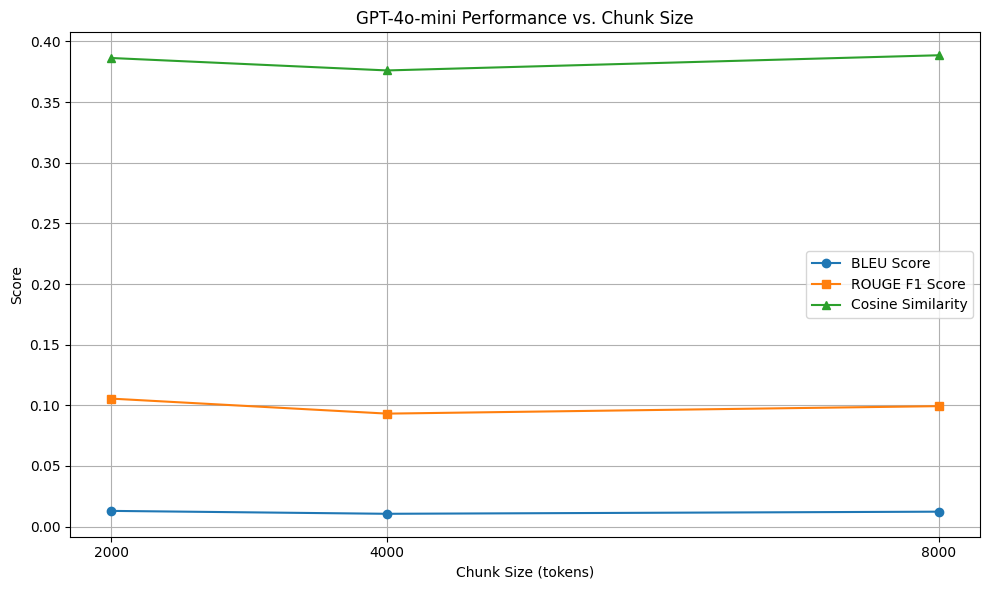

In [72]:
import seaborn as sns
import matplotlib.pyplot as plt

#Gpt model
plt.figure(figsize=(10, 6))
plt.plot(gpt_model["chunk_size"], gpt_model["bleu"], marker='o', label="BLEU Score")
plt.plot(gpt_model["chunk_size"], gpt_model["rouge_f1"], marker='s', label="ROUGE F1 Score")
plt.plot(gpt_model["chunk_size"], gpt_model["cosine"], marker='^', label="Cosine Similarity")

plt.title("GPT-4o-mini Performance vs. Chunk Size")
plt.xlabel("Chunk Size (tokens)")
plt.ylabel("Score")
plt.xticks(gpt_model["chunk_size"])
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

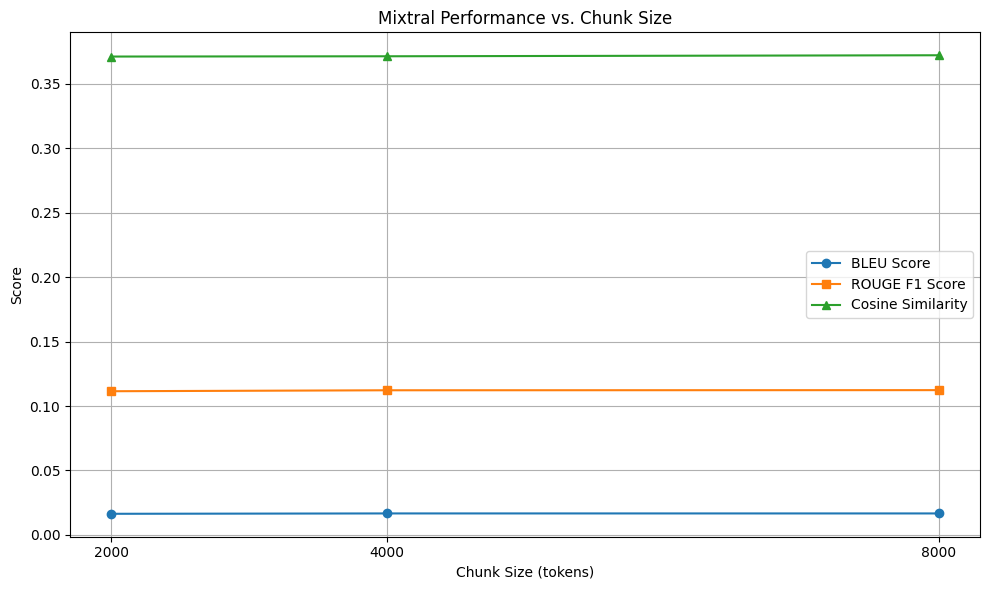

In [73]:
#Mixtral Model
plt.figure(figsize=(10, 6))
plt.plot(mixtral_only["chunk_size"], mixtral_only["bleu"], marker='o', label="BLEU Score")
plt.plot(mixtral_only["chunk_size"], mixtral_only["rouge_f1"], marker='s', label="ROUGE F1 Score")
plt.plot(mixtral_only["chunk_size"], mixtral_only["cosine"], marker='^', label="Cosine Similarity")

plt.title("Mixtral Performance vs. Chunk Size")
plt.xlabel("Chunk Size (tokens)")
plt.ylabel("Score")
plt.xticks(mixtral_only["chunk_size"])
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

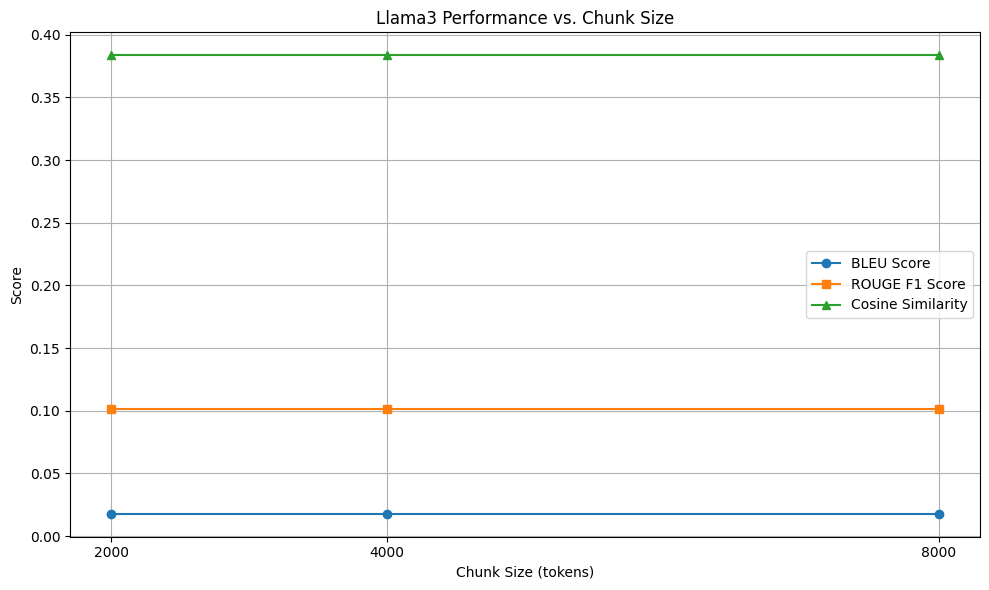

In [75]:
#Lmmama3 Model
plt.figure(figsize=(10, 6))
plt.plot(summary_model_llama3["chunk_size"],summary_model_llama3["bleu"], marker='o', label="BLEU Score")
plt.plot(summary_model_llama3["chunk_size"], summary_model_llama3["rouge_f1"], marker='s', label="ROUGE F1 Score")
plt.plot(summary_model_llama3["chunk_size"], summary_model_llama3["cosine"], marker='^', label="Cosine Similarity")

plt.title("Llama3 Performance vs. Chunk Size")
plt.xlabel("Chunk Size (tokens)")
plt.ylabel("Score")
plt.xticks(summary_model_llama3["chunk_size"])
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()